In [ ]:
import pennylane as qml
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,recall_score, f1_score,roc_auc_score, confusion_matrix,ConfusionMatrixDisplay, RocCurveDisplay)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch Device:", device)


Torch Device: cuda


In [35]:
# Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

X = StandardScaler().fit_transform(X)
X = PCA(n_components=4, random_state=42).fit_transform(X)
X = X / np.max(np.abs(X))
X = X * np.pi

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train = torch.tensor(X_train, dtype=torch.float64)
X_test  = torch.tensor(X_test, dtype=torch.float64)

y_train = torch.tensor(y_train, dtype=torch.float64)
y_test  = torch.tensor(y_test, dtype=torch.float64)


In [36]:
# Quantum Device
n_qubits = 4
n_layers = 8


@qml.qnode(dev, interface="torch")
def circuit(inputs, weights):

    qml.AngleEmbedding(
        inputs,
        wires=range(n_qubits),
        rotation="Y"
    )

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(n_qubits)
    )

    return qml.expval(qml.PauliZ(0))

    return [qml.expval(qml.PauliZ(i))
        for i in range(n_qubits)]
    out = torch.mean(outputs)

weight_shapes = {"weights": (n_layers, n_qubits, 3)}




In [ ]:
class QuantumLogisticRegression(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.weights = torch.nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, 3))

    def forward(self, x):
        outputs = []

        for sample in x:
            outputs.append(circuit(sample, self.weights))

        outputs = torch.stack(outputs)
        return torch.sigmoid(outputs)

In [ ]:
model = QuantumLogisticRegression()

optimizer = torch.optim.Adam(model.parameters(),lr=0.003)

criterion = torch.nn.BCELoss()

In [39]:
# Training
epochs = 200
batch_size = 32
loss_history = []

for epoch in range(epochs):
    permutation = torch.randperm(X_train.size(0))
    epoch_loss = 0.0

    for i in range(0, X_train.size(0), batch_size):
        idx = permutation[i:i+batch_size]
        xb = X_train[idx]
        yb = y_train[idx]

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= max(1, X_train.size(0)//batch_size)
    loss_history.append(epoch_loss)

    if (epoch+1)%10==0:
        print(f"Epoch {epoch+1:3d} Loss {epoch_loss:.4f}")


Epoch  10 Loss 0.5208
Epoch  20 Loss 0.5154
Epoch  30 Loss 0.5153
Epoch  40 Loss 0.5164
Epoch  50 Loss 0.5135
Epoch  60 Loss 0.5101
Epoch  70 Loss 0.5079
Epoch  80 Loss 0.5136
Epoch  90 Loss 0.5085
Epoch 100 Loss 0.5065
Epoch 110 Loss 0.5048
Epoch 120 Loss 0.5057
Epoch 130 Loss 0.5051
Epoch 140 Loss 0.5096
Epoch 150 Loss 0.5078
Epoch 160 Loss 0.5058
Epoch 170 Loss 0.5081
Epoch 180 Loss 0.5055
Epoch 190 Loss 0.5106
Epoch 200 Loss 0.5079


In [40]:
# Evaluation
model.eval()
with torch.no_grad():
    probs = model(X_test).cpu().numpy()

preds = (probs > 0.5).astype(int)
true = y_test.numpy()

print("Accuracy :", accuracy_score(true, preds))
print("Precision:", precision_score(true, preds))
print("Recall   :", recall_score(true, preds))
print("F1 Score :", f1_score(true, preds))
print("ROC AUC  :", roc_auc_score(true, probs))


Accuracy : 0.9385964912280702
Precision: 0.9113924050632911
Recall   : 1.0
F1 Score : 0.9536423841059603
ROC AUC  : 0.9841269841269841


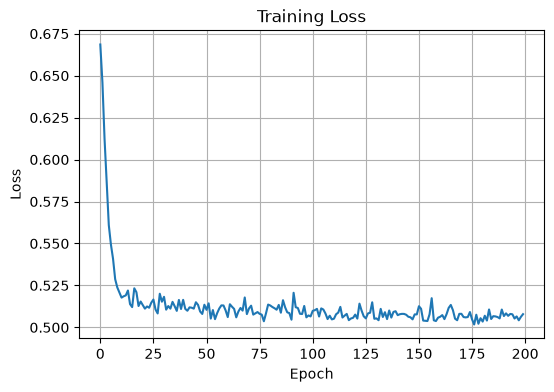

In [41]:
# Loss Plot
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


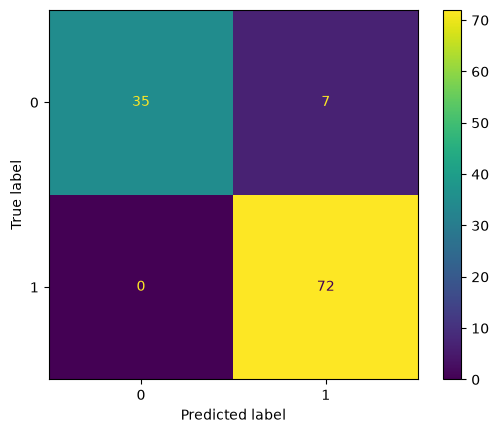

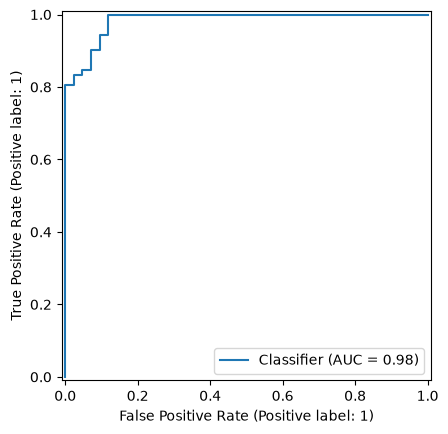

In [42]:
# Confusion Matrix
cm = confusion_matrix(true, preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(true, probs)
plt.show()


0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
3: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤     

M0 = 
tensor([-0.8157,  0.0355, -0.0628, -0.1133], dtype=torch.float64)
M1 = 
tensor([[[-2.5780e-01,  3.0828e-01,  2.4585e-01],
         [-1.9717e-02, -5.5364e-01,  3.5020e-01],
         [-1.8686e-01, -6.7616e-02, -5.2823e-01],
         [ 4.8246e-01,  1.9050e-01,  4.8292e-01]],

        [[-6.3961e-01,  1.6621e-01, -4.2931e-01],
         [ 2.7402e-01, -2.6585e-01,  5.1835e-01],
         [-2.6435e-01, -1.3685e-04,  4.5290e-02],
         [-2.1759e-01, -7.2851e-01,  1.6317e-01]],

        [[ 4.6239e-02,  6.4057e-01,  6.1392e-02],
         [ 1.3890e-01,  8.7218e-01,  6.2239e-01],
         [-3.5774e-01, -4.1272e-01, -9.4642e-01],
         [-3.9979e-01, -1.6630e-01,  1.7261e-01]],

        [[-7.7041e-01,  6.0914e-01,  1.5295e-01],
         [ 3.3671e-01

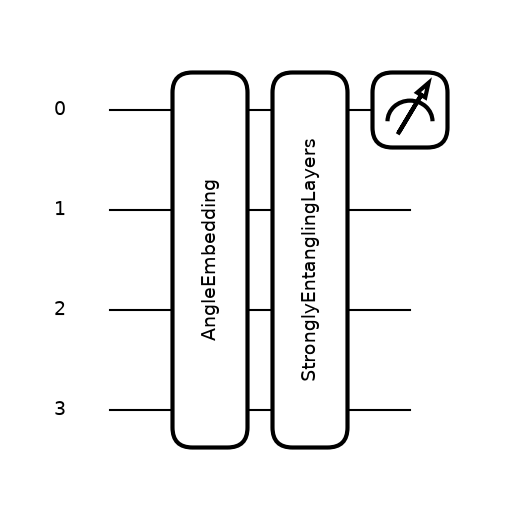

In [43]:
# Draw Quantum Circuit
sample_weights = next(model.parameters()).detach()
print(qml.draw(circuit)(X_train[0], sample_weights))

fig, ax = qml.draw_mpl(circuit)(X_train[0], sample_weights)
plt.show()


In [ ]:
# Save / Load
torch.save(model.state_dict(), "quantum_logistic_regression.pth")

new_model = QuantumLogisticRegression()
new_model.load_state_dict(torch.load("quantum_logistic_regression.pth"))
new_model.eval()

print("Model saved and loaded")


Model saved and loaded successfully.


C:\Users\Shreyash\AppData\Local\Temp\ipykernel_2700\880214791.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  new_model.load_state_dict(torch.load("quantum_logistic_regr